In [2]:
# ============================================================
# calibrar_classificador.py — Diagnóstico de limiares HSV (v2)
# ============================================================
# Agora inclui a feature `maior_blob_razao` (maior região colorida
# contígua), pra calibrar a arbitragem de bola branca única com dados
# reais em vez de suposição.

# --- Célula 1: imports e setup ---
import os
import cv2
import csv
import glob
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

CAMINHO_BASE       = os.path.join(os.path.dirname(os.getcwd()), 'data')
CAMINHO_NORMALIZED = os.path.join(CAMINHO_BASE, 'normalized')
CAMINHO_MODELO     = os.path.join(CAMINHO_BASE, '..', 'runs_sinuca', 'deteccao_bola', 'weights', 'best.pt')
CAMINHO_CSV        = os.path.join(CAMINHO_BASE, '..', 'calibracao_classificador.csv')

modelo_yolo = YOLO(CAMINHO_MODELO)

CLASSES_VALIDAS = ['branca', 'preta', 'lisa', 'listrada']

In [3]:
# --- Célula 2: extração de features (com maior_blob_razao) ---
def extrair_features(recorte_bgr):
    hsv = cv2.cvtColor(recorte_bgr, cv2.COLOR_BGR2HSV)
    h, w = hsv.shape[:2]

    raio = int(min(h, w) * 0.42)
    mascara = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(mascara, (w // 2, h // 2), raio, 255, -1)
    area_bola = cv2.countNonZero(mascara)
    if area_bola < 10:
        return None

    idx = mascara > 0
    S_vals = hsv[:, :, 1][idx].astype(np.float32)
    V_vals = hsv[:, :, 2][idx].astype(np.float32)

    v_mediana = float(np.median(V_vals))
    s_mediana = float(np.median(S_vals))
    razao_colorida = float(np.count_nonzero(S_vals > 90)) / area_bola

    glare = (V_vals > 245) & (S_vals < 25)
    branco_real = (S_vals < 55) & (V_vals > 150) & (~glare)
    razao_branco = float(np.count_nonzero(branco_real)) / area_bola
    razao_glare  = float(np.count_nonzero(glare)) / area_bola

    # --- maior blob colorido contíguo ---
    mascara_colorida = ((hsv[:, :, 1] > 90) & (mascara > 0)).astype(np.uint8)
    n_labels, labels = cv2.connectedComponents(mascara_colorida)
    maior_blob = 0
    for label in range(1, n_labels):
        tamanho = np.count_nonzero(labels == label)
        maior_blob = max(maior_blob, tamanho)
    maior_blob_razao = float(maior_blob) / area_bola

    return {
        'v_mediana': round(v_mediana, 1),
        's_mediana': round(s_mediana, 1),
        'razao_branco': round(razao_branco, 4),
        'razao_glare': round(razao_glare, 4),
        'razao_colorida': round(razao_colorida, 4),
        'maior_blob_razao': round(maior_blob_razao, 4),
    }

In [4]:
# --- Célula 3: rotulagem manual interativa ---
def rotular_dataset(pasta_imagens, modelo, conf=0.35):
    linhas = []
    caminhos = sorted(glob.glob(os.path.join(pasta_imagens, '*.JPG')) +
                       glob.glob(os.path.join(pasta_imagens, '*.jpg')))

    for caminho_img in caminhos:
        nome_base = os.path.basename(caminho_img)
        imagem = cv2.imread(caminho_img)
        pred = modelo.predict(imagem, conf=conf, verbose=False)[0]

        print(f'\n=== {nome_base}: {len(pred.boxes)} bolas detectadas ===')

        for i, box in enumerate(pred.boxes):
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(imagem.shape[1], x2), min(imagem.shape[0], y2)
            recorte = imagem[y1:y2, x1:x2]

            feats = extrair_features(recorte)
            if feats is None:
                continue

            plt.figure(figsize=(3, 3))
            plt.imshow(cv2.cvtColor(recorte, cv2.COLOR_BGR2RGB))
            plt.title(f'{nome_base} #{i} | V_med={feats["v_mediana"]} S_med={feats["s_mediana"]}\n'
                      f'branco={feats["razao_branco"]} colorida={feats["razao_colorida"]} '
                      f'blob={feats["maior_blob_razao"]}', fontsize=7)
            plt.axis('off')
            plt.show()

            plt.pause(0.1)

            rotulo = input(f'  Rótulo real (branca/preta/lisa/listrada, Enter=pular): ').strip().lower()
            if rotulo == '':
                continue
            if rotulo not in CLASSES_VALIDAS:
                print(f'  [AVISO] "{rotulo}" não é uma classe válida, pulando esta bola.')
                continue

            linhas.append({
                'imagem': nome_base, 'indice': i, 'rotulo_real': rotulo,
                **feats
            })

    return linhas


=== IMG_0640.JPG: 16 bolas detectadas ===


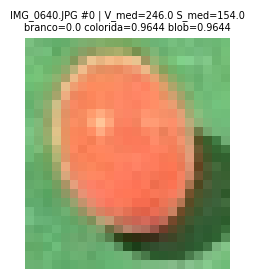

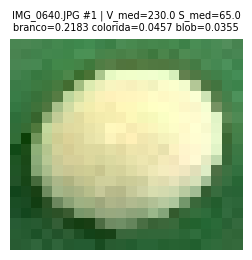

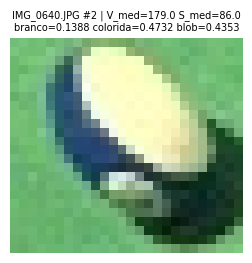

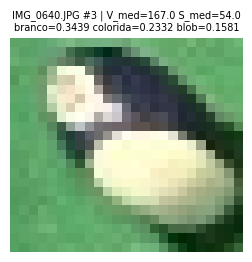

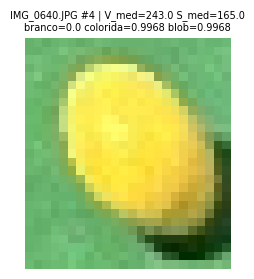

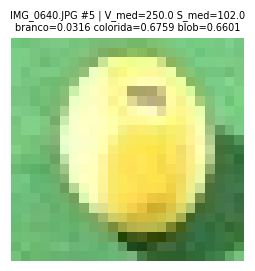

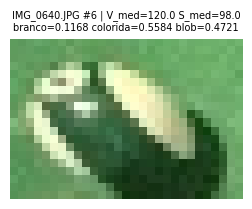

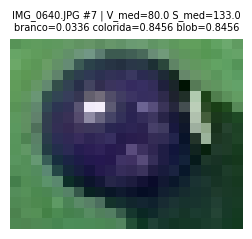

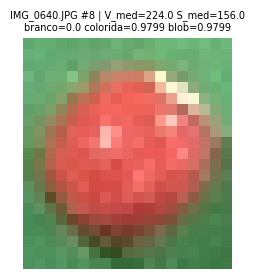

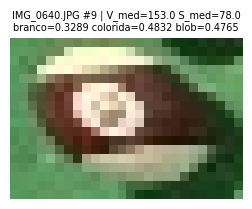

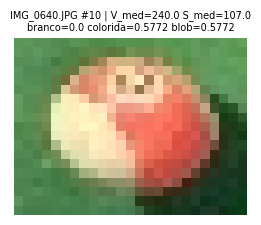

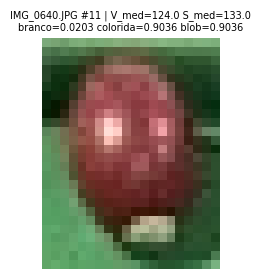

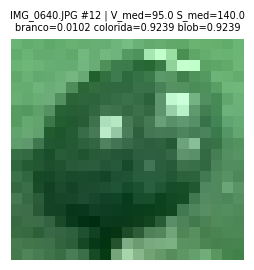

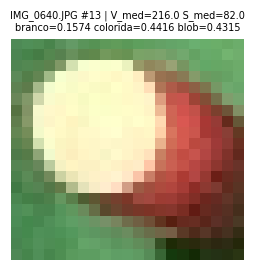

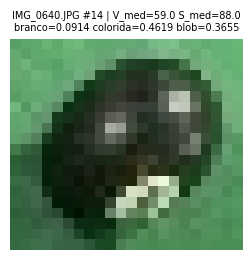

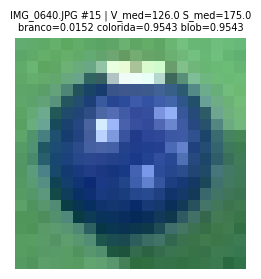


=== IMG_0641.JPG: 16 bolas detectadas ===


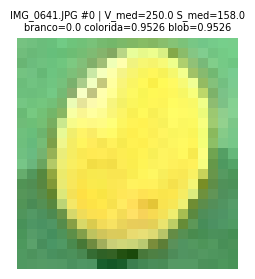

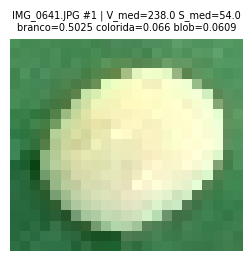

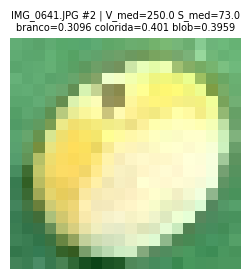

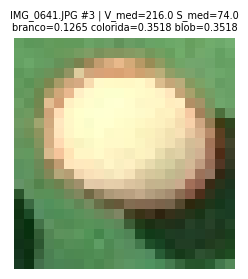

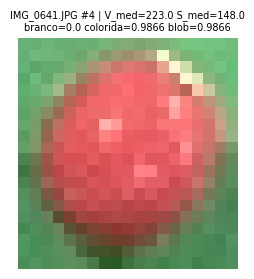

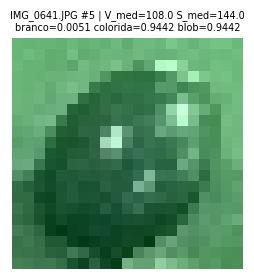

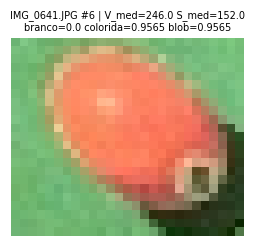

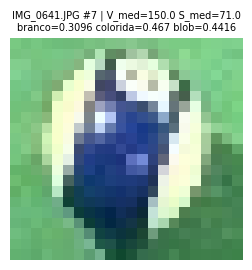

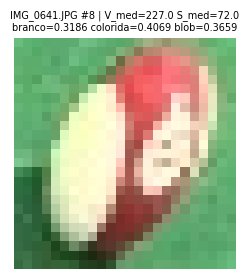

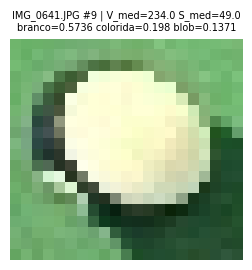

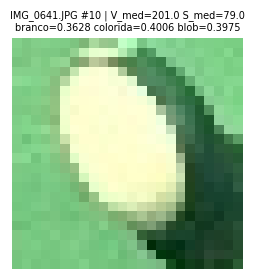

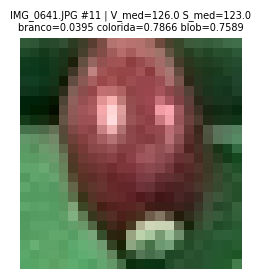

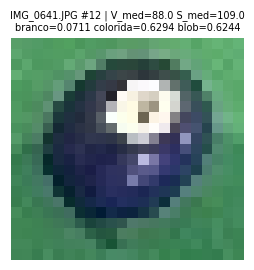

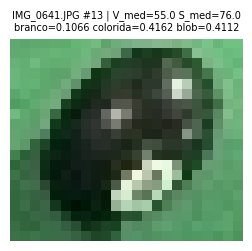

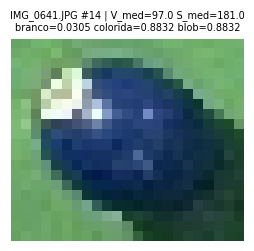

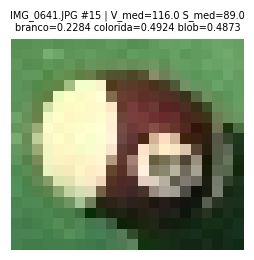


=== IMG_0642.JPG: 16 bolas detectadas ===


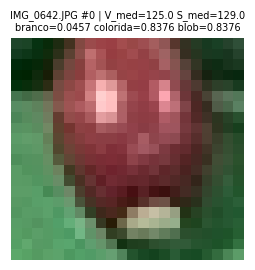

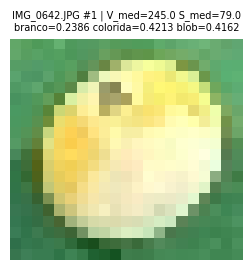

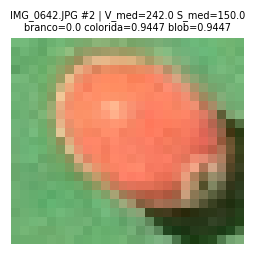

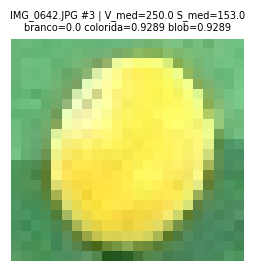

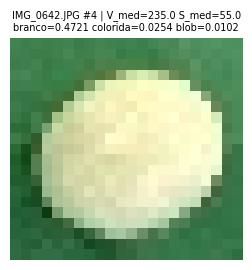

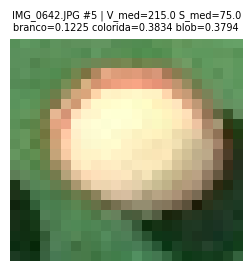

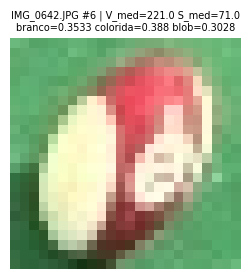

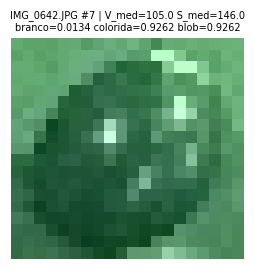

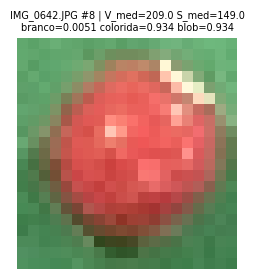

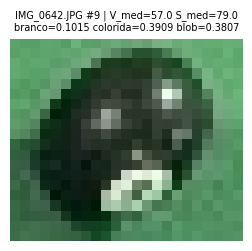

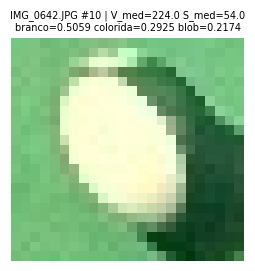

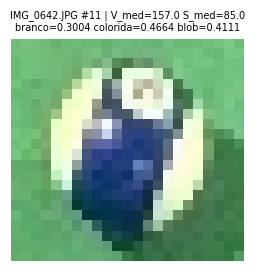

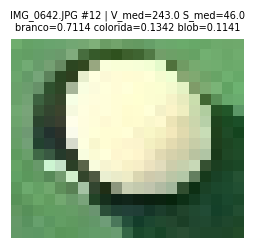

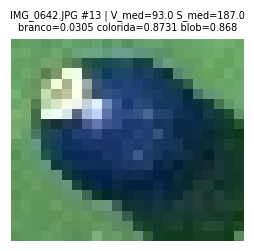

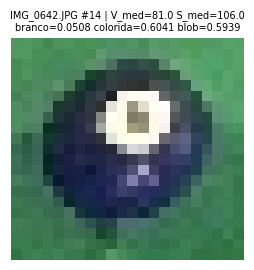

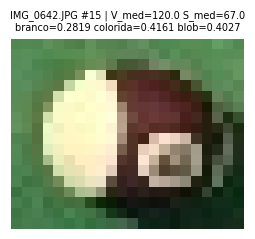


=== IMG_0643.JPG: 15 bolas detectadas ===


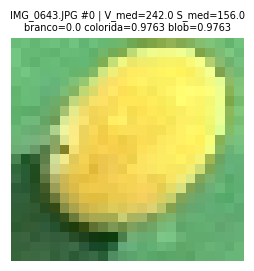

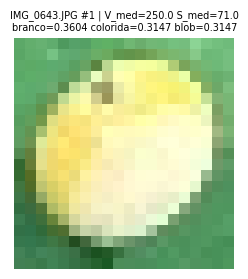

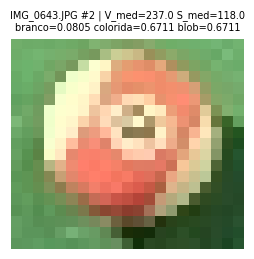

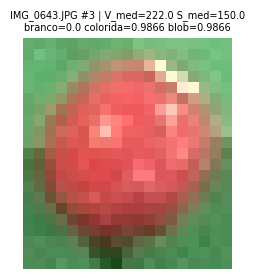

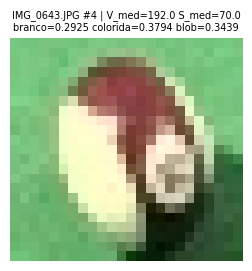

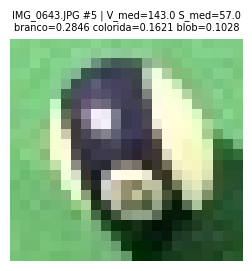

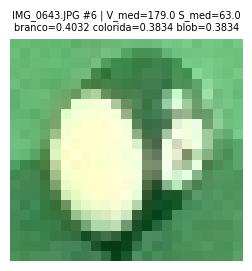

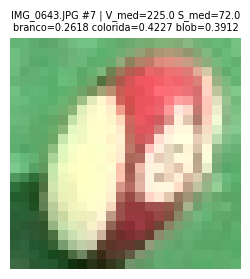

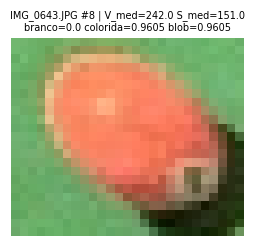

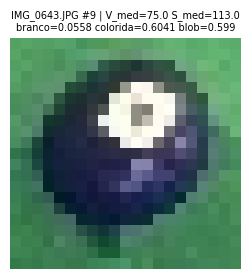

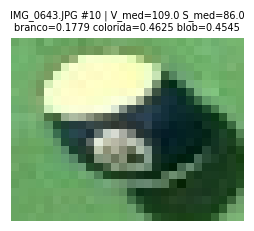

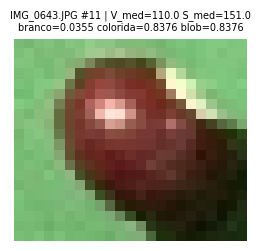

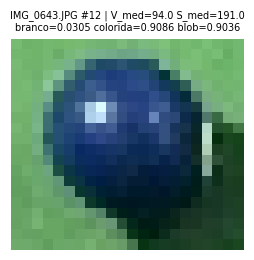

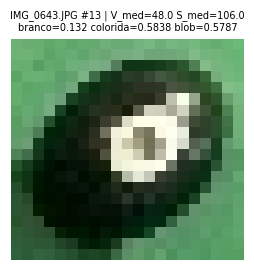

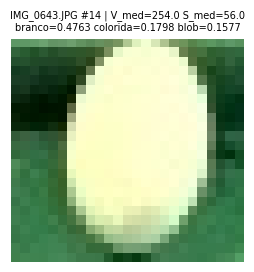


=== IMG_0644.JPG: 15 bolas detectadas ===


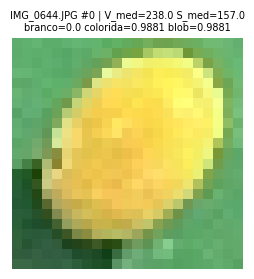

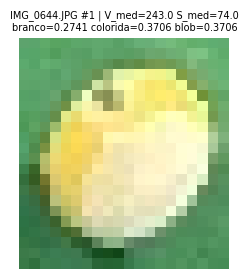

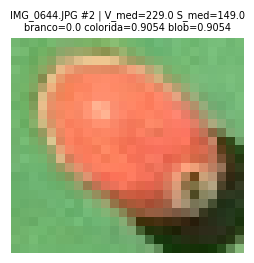

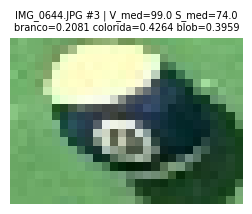

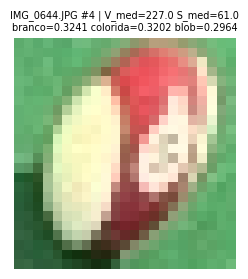

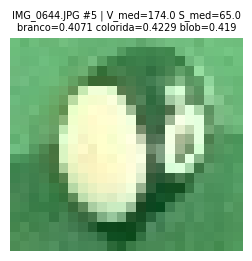

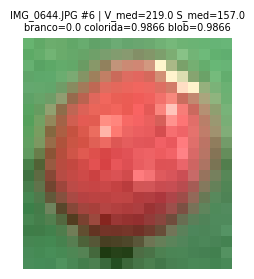

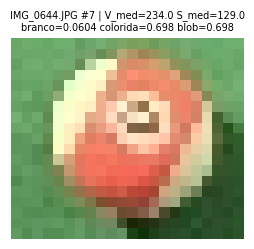

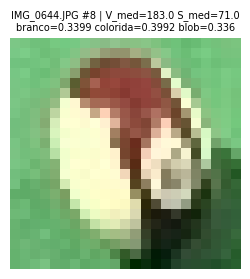

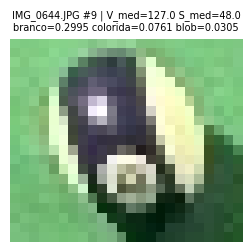

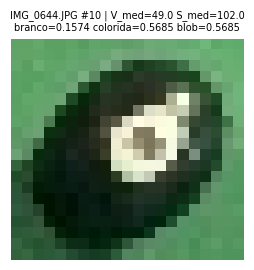

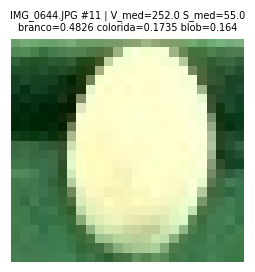

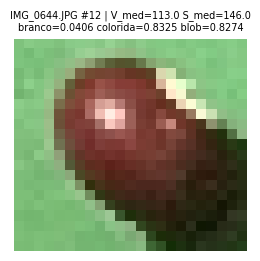

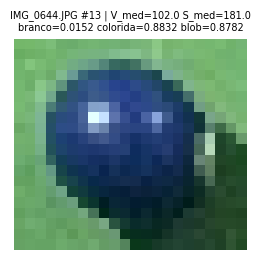

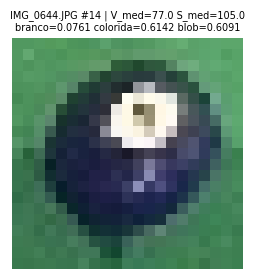


=== IMG_0645.JPG: 15 bolas detectadas ===


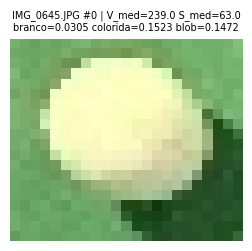

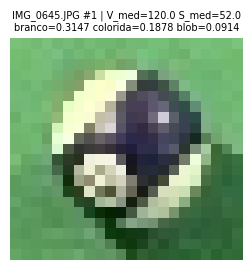

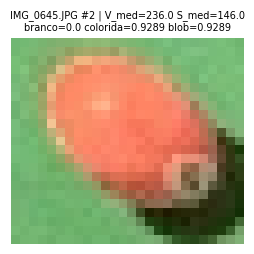

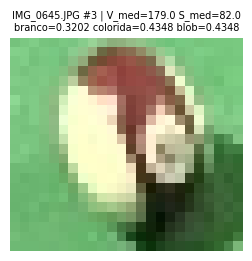

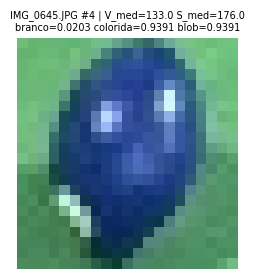

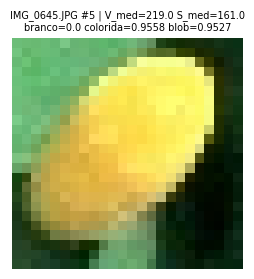

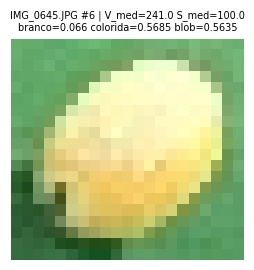

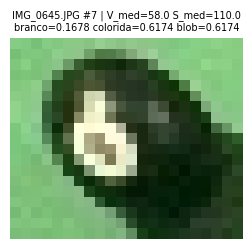

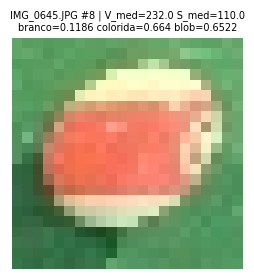

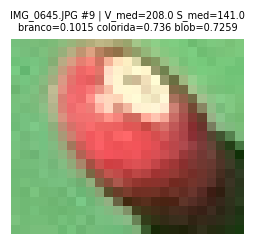

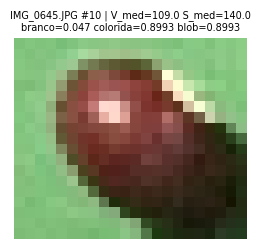

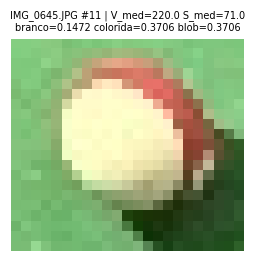

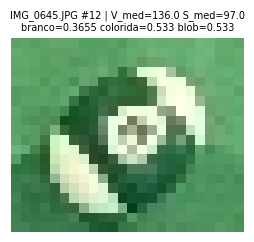

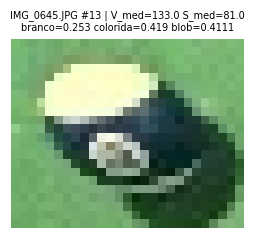

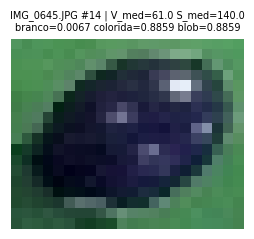


93 bolas rotuladas. CSV salvo em: /home/bridge/SinucaVision/data/../calibracao_classificador.csv


In [5]:
# --- Célula 4: roda a rotulagem e salva o CSV ---
linhas = rotular_dataset(CAMINHO_NORMALIZED, modelo_yolo)

with open(CAMINHO_CSV, 'w', newline='', encoding='utf-8') as f:
    campos = ['imagem', 'indice', 'rotulo_real', 'v_mediana', 's_mediana',
              'razao_branco', 'razao_glare', 'razao_colorida', 'maior_blob_razao']
    writer = csv.DictWriter(f, fieldnames=campos)
    writer.writeheader()
    writer.writerows(linhas)

print(f'\n{len(linhas)} bolas rotuladas. CSV salvo em: {CAMINHO_CSV}')

In [ ]:
# --- Célula 5: análise — boxplots por classe ---
import pandas as pd

df = pd.read_csv(CAMINHO_CSV)
print(df.groupby('rotulo_real')[['v_mediana', 's_mediana', 'razao_branco',
                                   'razao_colorida', 'maior_blob_razao']].describe().T)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, coluna in zip(axes, ['v_mediana', 's_mediana', 'razao_colorida', 'maior_blob_razao']):
    dados_por_classe = [df[df['rotulo_real'] == c][coluna].dropna() for c in CLASSES_VALIDAS]
    ax.boxplot(dados_por_classe, labels=CLASSES_VALIDAS)
    ax.set_title(coluna)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('''
Foco especial em "maior_blob_razao":
- A caixa da classe "branca" deve estar nitidamente abaixo de "listrada" e "lisa".
- Se uma listrada de faixa fina tiver maior_blob_razao parecido com o da branca,
  precisamos de outra feature (ex: circularidade do blob, ou posição relativa
  ao centro da bola) -- mas o esperado é que esta feature já resolva a maior
  parte dos casos, já que mede concentração e não só área total.
''')